# EEG S-JEPA Downstream Results Comparison

Aggregate and compare downstream fine-tuning results across paradigms and pretraining checkpoints.

- Paradigms: SSVEP, MI, ERP
- Fine-tuning schemes: configurable
- Pretraining checkpoints: 16s-60% (primary) + placeholders for extension
- Metrics: accuracy with error bars from cross-validation folds

# 1. Setup

## 1.1. Import Libraries

In [1]:
import sys
from pathlib import Path
import platform
import json
import hashlib
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Any

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as _cm
import matplotlib.lines as mlines

import builtins

_cmap = _cm.get_cmap("tab10")

/var/folders/7d/njk_0cn503z09dk98r0csptr0000gn/T/ipykernel_34881/1237693924.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap = _cm.get_cmap("tab10")


## 1.2. Runtime & Path Validation

In [2]:
print("Runtime Environment:")
print(f"  - Python: {sys.version}")
print(f"  - Platform: {platform.platform()}")

WORKING_DIR = Path.cwd().parent.parent
print(f"\nWorking directory: {WORKING_DIR}")

# Verify project structure
artifacts_dir = WORKING_DIR / "artifacts"
if not artifacts_dir.exists():
    raise FileNotFoundError(f"Artifacts directory not found at {artifacts_dir}")
else:
    print(f"Artifacts directory exists: {artifacts_dir}")

Runtime Environment:
  - Python: 3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.0.13.3)]
  - Platform: macOS-26.2-arm64-arm-64bit

Working directory: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA
Artifacts directory exists: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts


# 2. Configuration

## 2.1. Config

In [3]:
FT_SCHEME_ORDER = [
    "full-contextual",
    "full-post-local",
    "full-pre-local",
    "new-contextual",
    "new-post-local",
    "new-pre-local",
]

PRETRAINING_ORDER = [
    "1s-40%",
    "1s-60%",
    "1s-80%",
    "4s-40%",
    "4s-60%",
    "4s-80%",
    "16s-40%",
    "16s-60%",
    "16s-80%",
    "no-pre-training",
]

PARADIGM_ORDER = ["ERP", "SSVEP", "MI"]

CHANCE_LEVELS = {
    "ERP": 0.5,
    "SSVEP": 0.25,
    "MI": 0.5,
}

BEST_KNOWN_IN_PAPER = {
    "ERP": 0.97,
    "SSVEP": 0.94,
    "MI": 0.65,
}

BEST_KNOWN = {
    "ERP": 0.89,
    "SSVEP": 0.92,
    "MI": 0.54,
}

Y_LABELS = {
    "ERP": "Accuracy score",     # change to "ROC-AUC score" when ERP uses AUC
    "SSVEP": "Accuracy score",
    "MI": "Accuracy score",
}

PARADIGM_METRIC_KEYS = {
    "ERP": ("mean_accuracy", "std_accuracy"),    # swap to ("mean_roc_auc", "std_roc_auc") later
    "SSVEP": ("mean_accuracy", "std_accuracy"),
    "MI": ("mean_accuracy", "std_accuracy"),
}


PRETRAINING_COLORS = {pt: _cmap(i % 10) for i, pt in enumerate(PRETRAINING_ORDER)}

CONFIG = {
    # Output artifact directory for this notebook
    "artifact_dir": str(WORKING_DIR / "downstream_comparisons"),

    # Plotting controls
    "annotate_missing": False,
    "save_figures": True,
    "save_tables": False,

    # Figure dimensions
    "fig_width": 12,
    "fig_height_per_paradigm": 3,

    # Bar geometry
    "bar_width": 0.06,
    "group_gap": 1,   # spacing multiplier between the 6 groups

    # Font sizes for various plot elements
    "x_tick_fontsize": 13,
    "y_tick_fontsize": 13,
    "y_label_fontsize": 15,
    "dataset_label_fontsize": 15,
    "legend_fontsize": 13
}

print("Configuration loaded.")
print(f"  Paradigms : {PARADIGM_ORDER}")
print(f"  FT schemes: {FT_SCHEME_ORDER}")
print(f"  Pretraining checkpoints: {PRETRAINING_ORDER}")


Configuration loaded.
  Paradigms : ['ERP', 'SSVEP', 'MI']
  FT schemes: ['full-contextual', 'full-post-local', 'full-pre-local', 'new-contextual', 'new-post-local', 'new-pre-local']
  Pretraining checkpoints: ['1s-40%', '1s-60%', '1s-80%', '4s-40%', '4s-60%', '4s-80%', '16s-40%', '16s-60%', '16s-80%', 'no-pre-training']


## 2.2. Result Paths Mapping

In [4]:
# Scheme key names must match FT_SCHEME_ORDER exactly:
#   full-contextual | full-post-local | full-pre-local
#   new-contextual  | new-post-local  | new-pre-local

def _empty_pt_map() -> Dict:
    """Return a blank pre-training map with all 10 slots set to None."""
    return {pt: None for pt in PRETRAINING_ORDER}

RESULT_PATHS: Dict[str, Dict[str, Dict[str, Optional[str]]]] = {
    "ERP": {
        "full-contextual": _empty_pt_map(),
        "full-post-local": _empty_pt_map(),
        "full-pre-local":  _empty_pt_map(),
        "new-contextual":  {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/ERP/20260415_2106_45070b97",
        },
        "new-post-local":  {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/ERP/20260415_2057_f7ade870",
        },
        "new-pre-local":   {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/ERP/20260415_2024_06e2f4d8",
        },
    },
    "SSVEP": {
        "full-contextual": _empty_pt_map(),
        "full-post-local": {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/SSVEP/20260415_0002_33e6e683",
        },
        "full-pre-local":  {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/SSVEP/20260414_2309_6fffcc9d",
        },
        "new-contextual":  {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/SSVEP/20260414_1628_17dccc1e",
        },
        "new-post-local":  {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/SSVEP/20260414_1626_4fc84d8a",
        },
        "new-pre-local":   {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/SSVEP/20260414_1613_f1d1bf68",
        },
    },
    "MI": {
        "full-contextual": _empty_pt_map(),
        "full-post-local": {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/MI/20260415_1842_e3b5a534",
        },
        "full-pre-local":  {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/MI/20260415_1748_bd821a35",
        },
        "new-contextual":  {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/MI/20260415_1253_e64b3856",
        },
        "new-post-local":  {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/MI/20260415_1250_4f3e6fdd",
        },
        "new-pre-local":   {
            **_empty_pt_map(),
            "16s-60%": "artifacts/lee-2019-fine-tuning/MI/20260415_1243_fe097e91",
        },
    },
}

print("RESULT_PATHS initialized.")
print(f"  Paradigms configured: {list(RESULT_PATHS.keys())}")
for p, schemes in RESULT_PATHS.items():
    filled = sum(1 for s in schemes.values() for v in s.values() if v is not None)
    print(f"  {p}: {filled} non-None path(s)")

RESULT_PATHS initialized.
  Paradigms configured: ['ERP', 'SSVEP', 'MI']
  ERP: 3 non-None path(s)
  SSVEP: 5 non-None path(s)
  MI: 5 non-None path(s)


## 2.3. Create Artifact Directory

In [5]:
def create_run_id():
    """Generate unique run ID from timestamp + config hash."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    config_str = json.dumps(CONFIG, sort_keys=True, default=str)
    config_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
    return f"{timestamp}_project_comparison_{config_hash}"

RUN_ID = create_run_id()
ARTIFACT_DIR = Path(CONFIG["artifact_dir"]) / RUN_ID
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run ID: {RUN_ID}")
print(f"Artifact directory: {ARTIFACT_DIR}")

Run ID: 20260416_1226_project_comparison_f0225067
Artifact directory: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons/20260416_1226_project_comparison_f0225067


## 2.4. Initialize Logger

In [6]:
LOG_PATH = ARTIFACT_DIR / "run.log"
_LOG_FILE_HANDLE = open(LOG_PATH, "a", buffering=1)

def _timestamped_print(*args, **kwargs):
    """Print with timestamps to both console and log file."""
    sep = kwargs.pop("sep", " ")
    end = kwargs.pop("end", "\n")
    flush = kwargs.pop("flush", False)
    file = kwargs.pop("file", None)

    message = sep.join(str(arg) for arg in args)

    # Preserve visual spacing for prints like print("\n...")
    leading_newlines = len(message) - len(message.lstrip("\n"))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            sys.__stdout__.write(text) # type: ignore
            if flush:
                sys.__stdout__.flush() # type: ignore
        else:
            file.write(text)
            if flush and hasattr(file, "flush"):
                file.flush()

    # Apply leading blank lines first without timestamps
    if leading_newlines > 0:
        blanks = "\n" * leading_newlines
        _write_target(blanks)
        _LOG_FILE_HANDLE.write(blanks)

    if message_body:
        ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        stamped = f"[{ts}] {message_body}"
        _write_target(stamped + end)
        _LOG_FILE_HANDLE.write(stamped + end)
    else:
        # If only newlines were printed, preserve end behavior without adding a timestamp
        _write_target(end)
        _LOG_FILE_HANDLE.write(end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print
print("Logger initialized.")

[2026-04-16 12:26:15] Logger initialized.


## 2.5. Save Configuration

In [7]:
print("=" * 70)
print("CONFIGURATION")
print("=" * 70)
for key in sorted(CONFIG.keys()):
    print(f"  {key}: {CONFIG[key]}")
print("=" * 70)

config_path = ARTIFACT_DIR / "config.json"
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2, default=str)
print(f"Config saved to: {config_path}")

[2026-04-16 12:26:15] ======================================================================
[2026-04-16 12:26:15] CONFIGURATION
[2026-04-16 12:26:15] ======================================================================
[2026-04-16 12:26:15]   annotate_missing: False
[2026-04-16 12:26:15]   artifact_dir: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons
[2026-04-16 12:26:15]   bar_width: 0.06
[2026-04-16 12:26:15]   dataset_label_fontsize: 15
[2026-04-16 12:26:15]   fig_height_per_paradigm: 3
[2026-04-16 12:26:15]   fig_width: 12
[2026-04-16 12:26:15]   group_gap: 1
[2026-04-16 12:26:15]   legend_fontsize: 13
[2026-04-16 12:26:15]   save_figures: True
[2026-04-16 12:26:15]   save_tables: False
[2026-04-16 12:26:15]   x_tick_fontsize: 13
[2026-04-16 12:26:15]   y_label_fontsize: 15
[2026-04-16 12:26:15]   y_tick_fontsize: 13
[2026-04-16 12:26:15] ======================================================================
[2026-04-16 12:

# 3. Result Loading Utilities

## 3.1. Safe JSON Reader

In [8]:
def safe_read_json(file_path: Path) -> Tuple[Optional[Dict], str]:
    """
    Safely read JSON file and return data + status.
    
    Returns:
        (data_dict, status_str) where status is 'ok', 'missing_file', or 'json_error'
    """
    if not file_path.exists():
        return None, "missing_file"
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        return data, "ok"
    except json.JSONDecodeError as e:
        return None, f"json_error: {str(e)}"
    except Exception as e:
        return None, f"read_error: {str(e)}"

## 3.2. Metrics Loader

In [9]:
def load_metrics(
    paradigm: str,
    scheme: str,
    pretraining: str,
    run_path: Optional[str],
    metric_key: str,
    std_key: str,
) -> Dict[str, Any]:
    """
    Load metrics from global_metrics.json for a single configuration.
    
    Returns a dict with:
        - paradigm, scheme, pretraining (always present)
        - status: 'ok', 'missing_path', 'missing_metrics_file', 'json_error', 'missing_metric_key'
        - metric_value, std_value: populated if status == 'ok'
        - error_msg: human-readable error message
    """
    result = {
        "paradigm": paradigm,
        "scheme": scheme,
        "pretraining": pretraining,
        "status": None,
        "metric_value": None,
        "std_value": None,
        "error_msg": None,
    }
    
    # Check if path is configured
    if run_path is None:
        result["status"] = "missing_path"
        result["error_msg"] = "No path configured"
        return result
    
    # Resolve path
    run_path_obj = Path(run_path)
    if not run_path_obj.is_absolute():
        run_path_obj = WORKING_DIR / run_path_obj
    
    # Check if metrics file exists
    metrics_file = run_path_obj / "global_metrics.json"
    if not metrics_file.exists():
        result["status"] = "missing_metrics_file"
        result["error_msg"] = f"File not found: {metrics_file}"
        return result
    
    # Load JSON
    data, json_status = safe_read_json(metrics_file)
    if json_status != "ok":
        result["status"] = json_status if "error" in json_status else "json_error"
        result["error_msg"] = json_status
        return result
    
    # Extract metrics
    if metric_key not in data: # type: ignore
        result["status"] = "missing_metric_key"
        result["error_msg"] = f"Metric key '{metric_key}' not found in {metrics_file}"
        return result
    
    result["status"] = "ok"
    result["metric_value"] = float(data[metric_key]) # type: ignore
    result["std_value"] = float(data.get(std_key, 0.0)) # type: ignore
    
    return result

print("load_metrics defined.")

[2026-04-16 12:26:15] load_metrics defined.


## 3.3. Build Results Table

In [10]:

def build_full_expected_grid() -> pd.DataFrame:
    """
    Build the full Cartesian product of paradigm x ft_scheme x pretraining.
    Every expected position is present; metric columns default to NaN with is_missing=True.
    """
    rows = []
    for paradigm in PARADIGM_ORDER:
        for ft_scheme in FT_SCHEME_ORDER:
            for pretraining in PRETRAINING_ORDER:
                rows.append({
                    "paradigm": paradigm,
                    "ft_scheme": ft_scheme,
                    "pretraining": pretraining,
                    "metric_value": float("nan"),
                    "metric_std": float("nan"),
                    "is_missing": True,
                    "status": "not_configured",
                    "source_path": None,
                    "error_msg": None,
                })
    return pd.DataFrame(rows)


def load_all_metrics(result_paths: Dict) -> pd.DataFrame:
    """
    Walk RESULT_PATHS and return a DataFrame of successfully loaded rows.
    Uses per-paradigm metric keys from PARADIGM_METRIC_KEYS.
    Only returns rows where data was actually found (is_missing=False).
    """
    loaded_rows = []

    for paradigm in PARADIGM_ORDER:
        if paradigm not in result_paths:
            continue
        metric_key, std_key = PARADIGM_METRIC_KEYS[paradigm]

        for ft_scheme in FT_SCHEME_ORDER:
            if ft_scheme not in result_paths[paradigm]:
                continue  # scheme not populated; expected-grid will keep NaN for it

            for pretraining in PRETRAINING_ORDER:
                run_path = result_paths[paradigm][ft_scheme].get(pretraining)
                row = load_metrics(
                    paradigm=paradigm,
                    scheme=ft_scheme,
                    pretraining=pretraining,
                    run_path=run_path,
                    metric_key=metric_key,
                    std_key=std_key,
                )

                if row["status"] == "ok":
                    loaded_rows.append({
                        "paradigm": paradigm,
                        "ft_scheme": ft_scheme,
                        "pretraining": pretraining,
                        "metric_value": row["metric_value"],
                        "metric_std": row["std_value"],
                        "is_missing": False,
                        "status": "ok",
                        "source_path": run_path,
                        "error_msg": None,
                    })
                else:
                    # Record failure so we can report it, but do not fill the grid slot
                    loaded_rows.append({
                        "paradigm": paradigm,
                        "ft_scheme": ft_scheme,
                        "pretraining": pretraining,
                        "metric_value": float("nan"),
                        "metric_std": float("nan"),
                        "is_missing": True,
                        "status": row["status"],
                        "source_path": run_path,
                        "error_msg": row["error_msg"],
                    })

    return pd.DataFrame(loaded_rows) if loaded_rows else pd.DataFrame(
        columns=["paradigm", "ft_scheme", "pretraining", "metric_value",
                 "metric_std", "is_missing", "status", "source_path", "error_msg"]
    )


def build_merged_results() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Build the full expected grid, load available results, and merge.

    Returns:
        all_results   - full grid with loaded values merged in
        successful    - subset where is_missing == False
        missing       - subset where is_missing == True
    """
    grid = build_full_expected_grid()
    loaded = load_all_metrics(RESULT_PATHS)

    if len(loaded) == 0:
        return grid, pd.DataFrame(), grid

    # Merge loaded results into grid (left join keeps all expected positions)
    merge_keys = ["paradigm", "ft_scheme", "pretraining"]
    loaded_ok = loaded[loaded["status"] == "ok"][
        merge_keys + ["metric_value", "metric_std", "is_missing", "status", "source_path", "error_msg"]
    ].copy()

    # Update grid rows that have a matching loaded result
    grid = grid.set_index(merge_keys)
    loaded_ok = loaded_ok.set_index(merge_keys)
    grid.update(loaded_ok)
    grid = grid.reset_index()

    successful = grid[grid["is_missing"] == False].copy()  # noqa: E712
    missing = grid[grid["is_missing"] == True].copy()      # noqa: E712

    return grid, successful, missing

print("Grid-building helpers defined.")


[2026-04-16 12:26:15] Grid-building helpers defined.


# 4. Load and Inspect Results

## 4.1. Build Results DataFrame

In [11]:

print("\nBuilding full expected grid and merging loaded results...\n")

all_results, successful_results, missing_results = build_merged_results()

n_expected = len(PARADIGM_ORDER) * len(FT_SCHEME_ORDER) * len(PRETRAINING_ORDER)
print(f"Expected combinations (full grid): {n_expected}  ({len(PARADIGM_ORDER)} paradigms × {len(FT_SCHEME_ORDER)} schemes × {len(PRETRAINING_ORDER)} pretraining)")
print(f"Successfully loaded: {len(successful_results)}")
print(f"Missing / invalid:   {len(missing_results)}")



[2026-04-16 12:26:15] Building full expected grid and merging loaded results...

[2026-04-16 12:26:15] Expected combinations (full grid): 180  (3 paradigms × 6 schemes × 10 pretraining)
[2026-04-16 12:26:15] Successfully loaded: 13
[2026-04-16 12:26:15] Missing / invalid:   167


## 4.2. Loaded Results Overview

In [12]:
print("\n" + "=" * 70)
print("SUCCESSFULLY LOADED RESULTS")
print("=" * 70)

if len(successful_results) > 0:
    display_cols = ["paradigm", "ft_scheme", "pretraining", "metric_value", "metric_std", "status"]
    print(successful_results[display_cols].to_string(index=False))
else:
    print("No successful results loaded yet. Update RESULT_PATHS with actual artifact paths.")



[2026-04-16 12:26:15] ======================================================================
[2026-04-16 12:26:15] SUCCESSFULLY LOADED RESULTS
[2026-04-16 12:26:15] ======================================================================
[2026-04-16 12:26:15] paradigm       ft_scheme pretraining  metric_value   metric_std status
     ERP  new-contextual     16s-60%      0.833333 1.110223e-16     ok
     ERP  new-post-local     16s-60%      0.878608 2.022713e-02     ok
     ERP   new-pre-local     16s-60%      0.893831 2.402570e-02     ok
   SSVEP full-post-local     16s-60%      0.696429 2.176287e-01     ok
   SSVEP  full-pre-local     16s-60%      0.898571 1.514151e-01     ok
   SSVEP  new-contextual     16s-60%      0.250000 0.000000e+00     ok
   SSVEP  new-post-local     16s-60%      0.536429 1.969720e-01     ok
   SSVEP   new-pre-local     16s-60%      0.917857 1.205007e-01     ok
      MI full-post-local     16s-60%      0.572143 7.832429e-02     ok
      MI  full-pre-local     16

## 4.3. Missing Results Overview

In [13]:

print("\n" + "=" * 70)
print("MISSING OR INVALID RESULTS  (all expected positions without loaded data)")
print("=" * 70)

if len(missing_results) > 0:
    display_cols = ["paradigm", "ft_scheme", "pretraining", "status", "error_msg"]
    # Only print rows where path was actually configured but failed; skip plain not_configured clutter
    configured_failures = missing_results[missing_results["status"] != "not_configured"]
    not_configured = missing_results[missing_results["status"] == "not_configured"]

    if len(configured_failures) > 0:
        print("\nConfigured paths that failed to load:")
        print(configured_failures[display_cols].to_string(index=False))

    print(f"\nNot-yet-configured (path = None): {len(not_configured)} combinations")
    for paradigm in PARADIGM_ORDER:
        n = len(not_configured[not_configured["paradigm"] == paradigm])
        print(f"  {paradigm}: {n} not configured")
else:
    print("No missing results (all configured paths are valid).")



[2026-04-16 12:26:15] ======================================================================
[2026-04-16 12:26:15] MISSING OR INVALID RESULTS  (all expected positions without loaded data)
[2026-04-16 12:26:15] ======================================================================

[2026-04-16 12:26:15] Not-yet-configured (path = None): 167 combinations
[2026-04-16 12:26:15]   ERP: 57 not configured
[2026-04-16 12:26:15]   SSVEP: 55 not configured
[2026-04-16 12:26:15]   MI: 55 not configured


## 4.4. Coverage Summary

In [14]:
print("\n" + "=" * 70)
print("COVERAGE SUMMARY")
print("=" * 70)

# By paradigm
print("\nBy Paradigm:")
for paradigm in PARADIGM_ORDER:
    n_ok  = len(all_results[(all_results["paradigm"] == paradigm) & (all_results["is_missing"] == False)])  # noqa
    n_all = len(all_results[all_results["paradigm"] == paradigm])
    print(f"  {paradigm:8s}: {n_ok:3d} / {n_all:3d} loaded")

# By fine-tuning scheme
print("\nBy Fine-tuning Scheme:")
for scheme in FT_SCHEME_ORDER:
    n_ok  = len(all_results[(all_results["ft_scheme"] == scheme) & (all_results["is_missing"] == False)])  # noqa
    n_all = len(all_results[all_results["ft_scheme"] == scheme])
    print(f"  {scheme:20s}: {n_ok:3d} / {n_all:3d} loaded")

# By pretraining checkpoint
print("\nBy Pretraining Checkpoint:")
for pt in PRETRAINING_ORDER:
    n_ok  = len(all_results[(all_results["pretraining"] == pt) & (all_results["is_missing"] == False)])  # noqa
    n_all = len(all_results[all_results["pretraining"] == pt])
    print(f"  {pt:15s}: {n_ok:3d} / {n_all:3d} loaded")

print()



[2026-04-16 12:26:15] ======================================================================
[2026-04-16 12:26:15] COVERAGE SUMMARY
[2026-04-16 12:26:15] ======================================================================

[2026-04-16 12:26:15] By Paradigm:
[2026-04-16 12:26:15]   ERP     :   3 /  60 loaded
[2026-04-16 12:26:15]   SSVEP   :   5 /  60 loaded
[2026-04-16 12:26:15]   MI      :   5 /  60 loaded

[2026-04-16 12:26:15] By Fine-tuning Scheme:
[2026-04-16 12:26:15]   full-contextual     :   0 /  30 loaded
[2026-04-16 12:26:15]   full-post-local     :   2 /  30 loaded
[2026-04-16 12:26:15]   full-pre-local      :   2 /  30 loaded
[2026-04-16 12:26:15]   new-contextual      :   3 /  30 loaded
[2026-04-16 12:26:15]   new-post-local      :   3 /  30 loaded
[2026-04-16 12:26:15]   new-pre-local       :   3 /  30 loaded

[2026-04-16 12:26:15] By Pretraining Checkpoint:
[2026-04-16 12:26:15]   1s-40%         :   0 /  18 loaded
[2026-04-16 12:26:15]   1s-60%         :   0 /  18 lo

# 5. Plotting

## 5.1. Plot Helpers

In [15]:
N_SCHEMES     = len(FT_SCHEME_ORDER)
N_PRETRAINING = len(PRETRAINING_ORDER)
BAR_W         = CONFIG["bar_width"]
GROUP_SPAN    = N_PRETRAINING * BAR_W
GROUP_GAP     = CONFIG["group_gap"]

X_TICK_FONTSIZE = CONFIG["x_tick_fontsize"]
Y_TICK_FONTSIZE = CONFIG["y_tick_fontsize"]
Y_LABEL_FONTSIZE = CONFIG["y_label_fontsize"]
DATASET_LABEL_FONTSIZE = CONFIG["dataset_label_fontsize"]
LEGEND_FONTSIZE = CONFIG["legend_fontsize"]

# Group centers evenly spaced
GROUP_CENTERS = np.arange(N_SCHEMES) * (GROUP_SPAN + GROUP_GAP)

# Offset of each bar within its group (centered around 0)
BAR_OFFSETS = (np.arange(N_PRETRAINING) - (N_PRETRAINING - 1) / 2) * BAR_W

# x-tick labels for the 6 groups
SCHEME_LABELS = [s.replace("-", "\n", 1) for s in FT_SCHEME_ORDER]

In [16]:
def _get_value(grid: pd.DataFrame, paradigm: str, ft_scheme: str, pretraining: str):
    """Return (mean, std) for one grid cell, or (nan, nan) if missing."""
    mask = (
        (grid["paradigm"] == paradigm)
        & (grid["ft_scheme"] == ft_scheme)
        & (grid["pretraining"] == pretraining)
        & (grid["is_missing"] == False)  # noqa: E712
    )
    rows = grid[mask]
    if len(rows) == 0:
        return float("nan"), float("nan")
    row = rows.iloc[0]
    return float(row["metric_value"]), float(row["metric_std"])


def draw_paradigm_panel(
    ax,
    paradigm: str,
    grid: pd.DataFrame,
    is_last: bool = False,
) -> List:
    """
    Draw one paradigm panel with:
      - 6 group centers (one per FT scheme)
      - 10 bars per group (one per pre-training condition)
      - empty slot preserved for missing combinations
      - thin black error bars (no caps)
      - blue dashed chance line
      - green dashed best-known line
      - red dashed best-known-in-paper line
      - bold dashed gray vertical group separators
      - right-side paradigm label

    Returns list of (bar_patch, pretraining_label) pairs for legend building.
    """
    legend_handles = []
    seen_labels = set()

    for pt_idx, pretraining in enumerate(PRETRAINING_ORDER):
        color = PRETRAINING_COLORS[pretraining]

        for grp_idx, ft_scheme in enumerate(FT_SCHEME_ORDER):
            mean, std = _get_value(grid, paradigm, ft_scheme, pretraining)

            if not np.isnan(mean):
                x = GROUP_CENTERS[grp_idx] + BAR_OFFSETS[pt_idx]
                bar = ax.bar(
                    x, mean, BAR_W,
                    color=color,
                    linewidth=0,
                    zorder=3,
                )
                # Error bar — thin black vertical line only (no horizontal caps)
                ax.errorbar(
                    x,
                    mean,
                    yerr=std if not np.isnan(std) else 0.0,
                    fmt="none",
                    color="black",
                    linewidth=0.8,
                    capsize=0,
                    zorder=4,
                )
                if pretraining not in seen_labels:
                    seen_labels.add(pretraining)
                    legend_handles.append((bar.patches[0], pretraining))

    chance = CHANCE_LEVELS.get(paradigm, 0.5)
    best = BEST_KNOWN.get(paradigm)
    best_in_paper = BEST_KNOWN_IN_PAPER.get(paradigm)

    chance_color = "#2166ac"
    best_color = "#4dd65d"
    best_in_paper_color = "#d6604d"

    xlim_lo = GROUP_CENTERS[0] - GROUP_SPAN * 0.6
    xlim_hi = GROUP_CENTERS[-1] + GROUP_SPAN * 0.6

    ax.axhline(
        chance,
        color=chance_color,
        linestyle="--",
        linewidth=1.2,
        label="Chance level",
        zorder=2,
        alpha=0.85,
    )

    ax.axhline(
        best,
        color=best_color,
        linestyle="--",
        linewidth=1.2,
        label="Best known",
        zorder=2,
        alpha=0.85,
    )

    ax.axhline(
        best_in_paper,
        color=best_in_paper_color,
        linestyle="--",
        linewidth=1.2,
        label="Best known in paper",
        zorder=2,
        alpha=0.85,
    )

    for grp_idx in range(1, N_SCHEMES):
        sep_x = (GROUP_CENTERS[grp_idx - 1] + GROUP_CENTERS[grp_idx]) / 2
        ax.axvline(sep_x, color="gray", linestyle="--", linewidth=1.4, zorder=1, alpha=0.85)

    # Match panel scales to paper-like layout:
    # ERP and MI start at 0.4, SSVEP starts at 0.2.
    y_limits = {
        "ERP": (0.4, 1.0),
        "SSVEP": (0.2, 1.0),
        "MI": (0.4, 0.8),
    }
    y_min, y_max = y_limits.get(paradigm, (0.0, 1.0))

    ax.set_xlim(xlim_lo, xlim_hi)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(GROUP_CENTERS)
    ax.set_xticklabels(SCHEME_LABELS, fontsize=X_TICK_FONTSIZE)

    # Keep base ticks, and also include chance/best/best-in-paper values.
    base_ticks = [0.4, 0.6, 0.8]
    ref_ticks = [float(chance), float(best), float(best_in_paper)]
    all_ticks = sorted({round(t, 4) for t in (base_ticks + ref_ticks) if y_min <= t <= y_max})
    ax.set_yticks(all_ticks)
    ax.set_yticklabels([f"{t:.2f}" if t in ref_ticks else f"{t:.1f}" for t in all_ticks], fontsize=Y_TICK_FONTSIZE)

    # Color reference-value labels to match lines.
    for lbl, t in zip(ax.get_yticklabels(), all_ticks):
        if abs(t - chance) < 1e-6:
            lbl.set_color(chance_color)
        elif abs(t - best) < 1e-6:
            lbl.set_color(best_color)
        elif abs(t - best_in_paper) < 1e-6:
            lbl.set_color(best_in_paper_color)
        else:
            lbl.set_color("black")

    ax.set_ylabel(Y_LABELS.get(paradigm, "Score"), fontsize=Y_LABEL_FONTSIZE)
    ax.grid(axis="y", alpha=0.25, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Right-side paradigm label (paper style)
    label_name = f"lee2019-{paradigm.lower()}"
    ax.annotate(
        label_name,
        xy=(1, 0.5),
        xycoords="axes fraction",
        fontsize=DATASET_LABEL_FONTSIZE,
        va="center",
        ha="left",
        rotation=270,
        annotation_clip=False,
    )

    return legend_handles


def build_legend_handles():
    """
    Build separate legend groups:
      1) Pre-training weights (always show all configured weights)
      2) Reference lines (chance/best/best-in-paper)
    """
    weight_handles = [
        mlines.Line2D(
            [], [], linestyle="None", marker="s", markersize=12,
            markerfacecolor=PRETRAINING_COLORS[pt], markeredgewidth=0,
            label=pt,
        )
        for pt in PRETRAINING_ORDER
    ]
    weight_labels = PRETRAINING_ORDER.copy()

    reference_handles = [
        mlines.Line2D([], [], color="#2166ac", linestyle="--", linewidth=2.2, label="chance level"),
        mlines.Line2D([], [], color="#4dd65d", linestyle="--", linewidth=2.2, label="best"),
        mlines.Line2D([], [], color="#d6604d", linestyle="--", linewidth=2.2, label="best in paper"),
    ]
    reference_labels = ["chance level", "best", "best in paper"]

    return weight_handles, weight_labels, reference_handles, reference_labels


print("Paper-style plot helpers defined.")
print(f"  Group centers : {np.round(GROUP_CENTERS, 2)}")
print(f"  Bar width     : {BAR_W}")
print(f"  Group span    : {GROUP_SPAN:.2f}")


[2026-04-16 12:26:15] Paper-style plot helpers defined.
[2026-04-16 12:26:15]   Group centers : [0.  1.6 3.2 4.8 6.4 8. ]
[2026-04-16 12:26:15]   Bar width     : 0.06
[2026-04-16 12:26:15]   Group span    : 0.60


## 5.2. Paradigm-wise Comparison Plot


[2026-04-16 12:29:35] Paper-style comparison figure created.


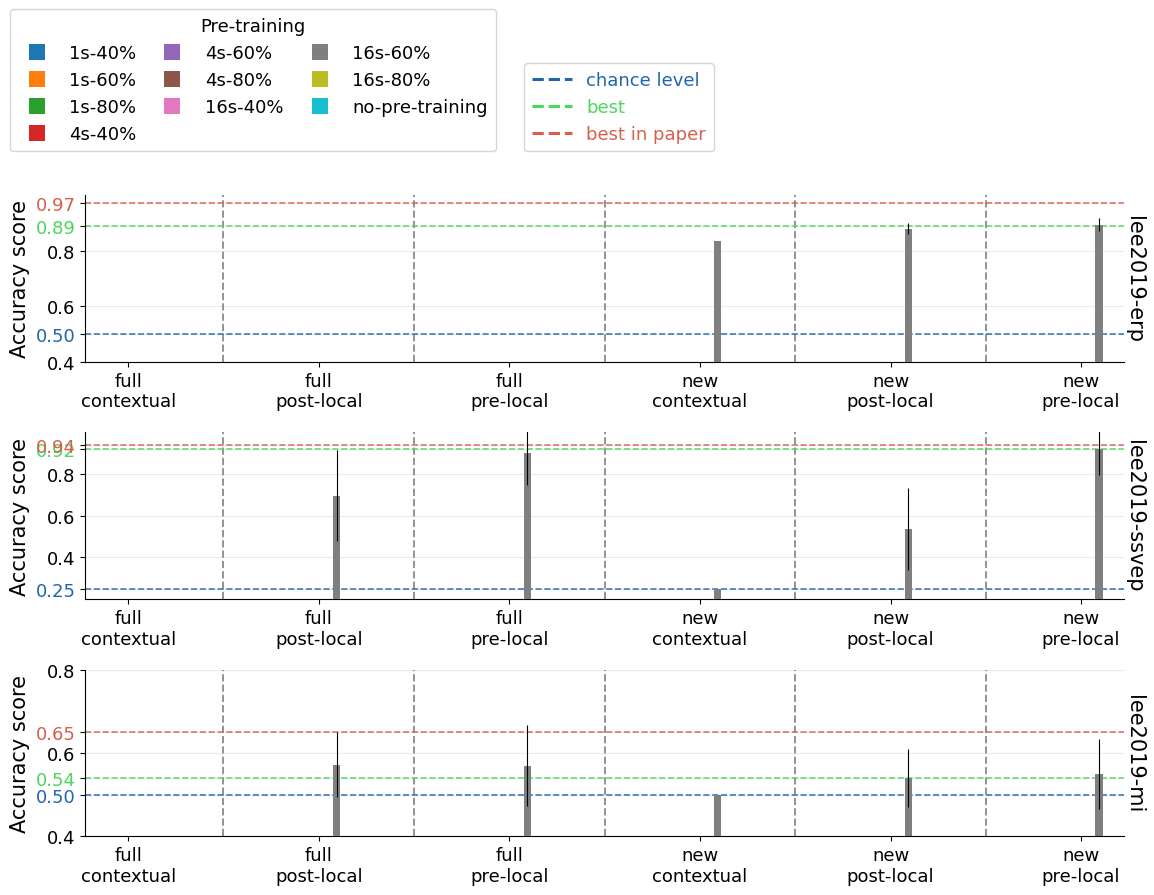

In [30]:

fig_h = CONFIG["fig_height_per_paradigm"] * len(PARADIGM_ORDER)
fig_w = CONFIG["fig_width"]

fig, axes = plt.subplots(
    len(PARADIGM_ORDER), 1,
    figsize=(fig_w, fig_h),
    sharex=False,
)


for row_idx, paradigm in enumerate(PARADIGM_ORDER):
    ax = axes[row_idx]
    panel_handles = draw_paradigm_panel(
        ax=ax,
        paradigm=paradigm,
        grid=all_results,
        is_last=(row_idx == len(PARADIGM_ORDER) - 1),
    )

weight_handles, weight_labels, reference_handles, reference_labels = build_legend_handles()

weights_legend = fig.legend(
    weight_handles,
    weight_labels,
    title="Pre-training",
    loc="upper center",
    bbox_to_anchor=(0.215, 1),
    ncol=3,
    fontsize=LEGEND_FONTSIZE,
    title_fontsize=LEGEND_FONTSIZE,
    frameon=True,
    borderpad=0.45,
    columnspacing=1.0,
    handlelength=2.0,
)

refs_legend = fig.legend(
    reference_handles,
    reference_labels,
    loc="upper center",
    bbox_to_anchor=(0.52, 0.94),
    ncol=1,
    fontsize=LEGEND_FONTSIZE,
    frameon=True,
    borderpad=0.45,
    handlelength=2.2,
)

# Match legend text color to line colors for easier reading
for txt, handle in zip(refs_legend.get_texts(), reference_handles):
    txt.set_color(handle.get_color())

plt.tight_layout(rect=[0, 0, 0.97, 0.80])  # reserve top space for larger legends
print("\nPaper-style comparison figure created.")
plt.show()


# 6. Save Outputs

## 6.1. Save Figure

In [18]:
if CONFIG["save_figures"]:
    png_path = ARTIFACT_DIR / "comparison_plot.png"
    pdf_path = ARTIFACT_DIR / "comparison_plot.pdf"
    
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    
    print("Figure saved:")
    print(f"  - PNG: {png_path}")
    print(f"  - PDF: {pdf_path}")
else:
    print("Figure saving disabled in CONFIG.")

[2026-04-16 12:26:15] Figure saved:
[2026-04-16 12:26:15]   - PNG: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons/20260416_1226_project_comparison_f0225067/comparison_plot.png
[2026-04-16 12:26:15]   - PDF: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons/20260416_1226_project_comparison_f0225067/comparison_plot.pdf


## 6.2. Save Results Table

In [19]:

if CONFIG["save_tables"]:
    # Successful results
    csv_path  = ARTIFACT_DIR / "results_table.csv"
    json_path = ARTIFACT_DIR / "results_table.json"
    successful_results.to_csv(csv_path, index=False)
    successful_results.to_json(json_path, orient="records", indent=2)
    print("Results table saved:")
    print(f"  - CSV:  {csv_path}")
    print(f"  - JSON: {json_path}")

    # Missing results — always save for diagnostics
    missing_csv_path = ARTIFACT_DIR / "missing_results.csv"
    missing_results.to_csv(missing_csv_path, index=False)
    print(f"  - Missing CSV: {missing_csv_path}  ({len(missing_results)} rows)")
else:
    print("Table saving disabled in CONFIG.")


[2026-04-16 12:26:15] Table saving disabled in CONFIG.


## 6.3. Save Summary

In [20]:

summary = {
    "run_id": RUN_ID,
    "timestamp": datetime.now().isoformat(),
    "total_expected_combinations": len(all_results),
    "total_successfully_loaded": len(successful_results),
    "total_missing_or_invalid": len(missing_results),
    "ft_scheme_order": FT_SCHEME_ORDER,
    "pretraining_order": PRETRAINING_ORDER,
    "paradigm_metric_keys": {k: list(v) for k, v in PARADIGM_METRIC_KEYS.items()},
    "paradigm_coverage": {
        paradigm: {
            "loaded": int((all_results["paradigm"] == paradigm).sum() -
                          (missing_results["paradigm"] == paradigm).sum()),
            "total": int((all_results["paradigm"] == paradigm).sum()),
        }
        for paradigm in PARADIGM_ORDER
    },
    "output_files": {
        "config": "config.json",
        "results_csv": "results_table.csv",
        "results_json": "results_table.json",
        "missing_csv": "missing_results.csv",
        "plot_png": "comparison_plot.png",
        "plot_pdf": "comparison_plot.pdf",
        "log": "run.log",
    },
}

summary_path = ARTIFACT_DIR / "summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Summary saved to: {summary_path}")


[2026-04-16 12:26:15] Summary saved to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons/20260416_1226_project_comparison_f0225067/summary.json


# 7. Final Summary

In [21]:
print(f"\nRun ID: {RUN_ID}")
print(f"Artifact Directory: {ARTIFACT_DIR}")

print(f"\nGrid dimensions: {len(PARADIGM_ORDER)} paradigms × {len(FT_SCHEME_ORDER)} FT schemes × {len(PRETRAINING_ORDER)} pretraining = {len(all_results)} slots")
print(f"  Successfully loaded : {len(successful_results)}")
print(f"  Missing / invalid   : {len(missing_results)}")

print("\nCoverage by Paradigm:")
for paradigm in PARADIGM_ORDER:
    n_ok  = len(all_results[(all_results["paradigm"] == paradigm) & (all_results["is_missing"] == False)])  # noqa
    n_all = len(all_results[all_results["paradigm"] == paradigm])
    pct   = 100 * n_ok / n_all if n_all > 0 else 0.0
    print(f"  {paradigm:8s}: {n_ok:3d} / {n_all:3d} ({pct:5.1f}%)")

print("\nGenerated Outputs:")
for artifact in sorted(ARTIFACT_DIR.iterdir()):
    size_kb = artifact.stat().st_size / 1024
    print(f"  - {artifact.name:35s} ({size_kb:7.1f} KB)")


[2026-04-16 12:26:15] Run ID: 20260416_1226_project_comparison_f0225067
[2026-04-16 12:26:15] Artifact Directory: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons/20260416_1226_project_comparison_f0225067

[2026-04-16 12:26:15] Grid dimensions: 3 paradigms × 6 FT schemes × 10 pretraining = 180 slots
[2026-04-16 12:26:15]   Successfully loaded : 13
[2026-04-16 12:26:15]   Missing / invalid   : 167

[2026-04-16 12:26:15] Coverage by Paradigm:
[2026-04-16 12:26:15]   ERP     :   3 /  60 (  5.0%)
[2026-04-16 12:26:15]   SSVEP   :   5 /  60 (  8.3%)
[2026-04-16 12:26:15]   MI      :   5 /  60 (  8.3%)

[2026-04-16 12:26:15] Generated Outputs:
[2026-04-16 12:26:15]   - comparison_plot.pdf                 (   16.8 KB)
[2026-04-16 12:26:15]   - comparison_plot.png                 (  135.4 KB)
[2026-04-16 12:26:15]   - config.json                         (    0.4 KB)
[2026-04-16 12:26:15]   - run.log                             (    6.6 KB